#  Visualization Results

Đọc kết quả từ CSV và vẽ biểu đồ.

✓ Loaded: correctness_results.csv
✓ Loaded: time_fi_results.csv
✓ Loaded: memory_results.csv
✓ Loaded: scalability_results.csv
✓ Loaded: txlen_results.csv

=== CORRECTNESS RESULTS ===


,Dataset,Minsup_Pct,Minsup_Count,Num_FI_Our,Num_FI_SPMF,Matched,Match_Rate_Pct,Analysis
0,Chess,85.0,2717,2669,2669,2669,100.0,MATCH
1,Chess,80.0,2557,8227,8227,8227,100.0,MATCH
2,Chess,75.0,2397,20993,20993,20993,100.0,MATCH
3,Mushroom,30.0,2438,2735,2735,2735,100.0,MATCH
4,Mushroom,25.0,2031,5545,5545,5545,100.0,MATCH
5,Mushroom,20.0,1625,53583,53583,53583,100.0,MATCH
6,Retail,5.0,4409,16,16,16,100.0,MATCH
7,Retail,3.0,2645,32,32,32,100.0,MATCH
8,Retail,2.0,1764,55,55,55,100.0,MATCH
9,Accidents,90.0,306165,31,31,31,100.0,MATCH



=== TIME & FI RESULTS ===


,Dataset,Minsup_Pct,Time_Basic_ms,Time_Opt_ms,Time_SPMF_ms,Num_FI
0,Chess,90.0,21.10,13.82,326.19,622
1,Chess,85.0,86.43,54.73,361.57,2669
2,Chess,80.0,398.44,168.97,372.60,8227
3,Chess,75.0,859.93,415.04,380.03,20993
4,Chess,70.0,1441.52,956.27,389.62,48731
5,Chess,65.0,2990.16,2007.67,427.32,111239
6,Mushroom,40.0,39.69,28.18,377.69,565
7,Mushroom,35.0,57.31,57.39,352.47,1189
8,Mushroom,30.0,177.07,163.49,376.41,2735
9,Mushroom,25.0,213.93,228.92,378.11,5545


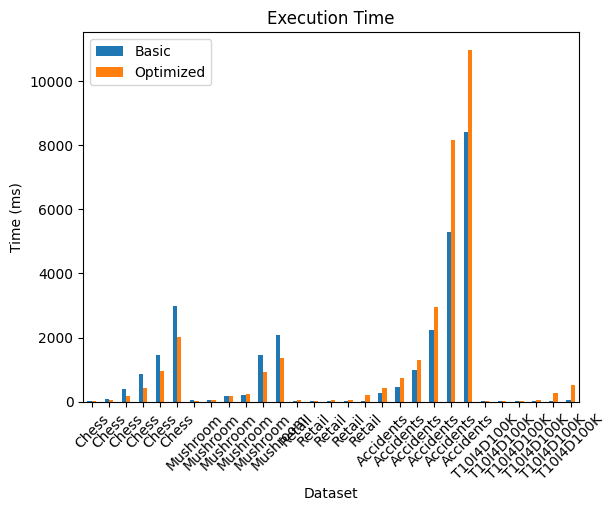


=== MEMORY RESULTS ===


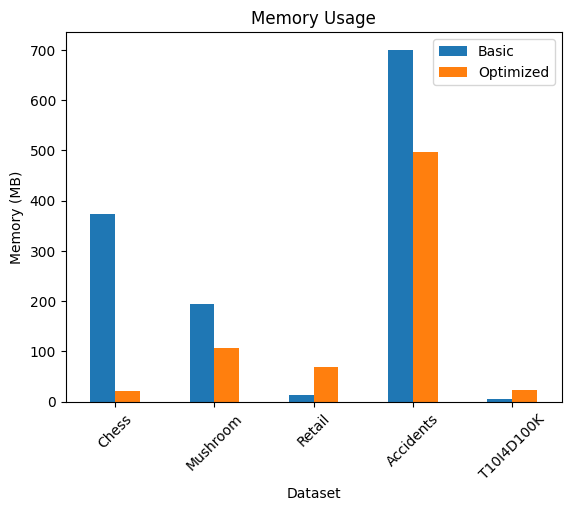


=== SCALABILITY RESULTS ===


,Subset_Pct,Num_Trans,Minsup_Count,Time_Basic_ms,Time_Opt_ms,Num_FI_Basic,Num_FI_Opt,Trend
0,10,8817,177,4.31,6.55,63,63,Baseline
1,25,22041,441,7.95,31.67,59,59,Sublinear
2,50,44081,882,17.08,134.31,59,59,Linear
3,75,66122,1323,24.53,139.88,54,54,Linear
4,100,88162,1764,30.06,166.86,55,55,Linear


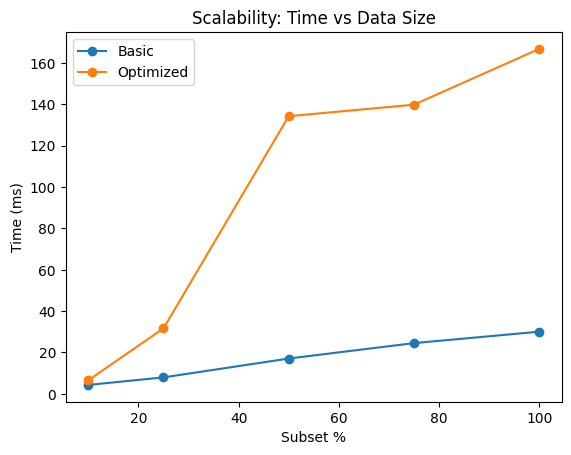


=== TX LENGTH RESULTS ===


,Avg_TxLen,Time_Basic_ms,Time_Opt_ms,Num_FI_Basic,Num_FI_Opt,Analysis
0,5,0.97,0.98,0,0,Low_impact
1,10,1.40,1.98,0,0,Medium_impact
2,15,2.26,2.98,0,0,Medium_impact
3,20,2.57,2.36,0,0,High_impact
4,25,3.06,3.28,0,0,High_impact
5,30,3.29,3.70,0,0,High_impact


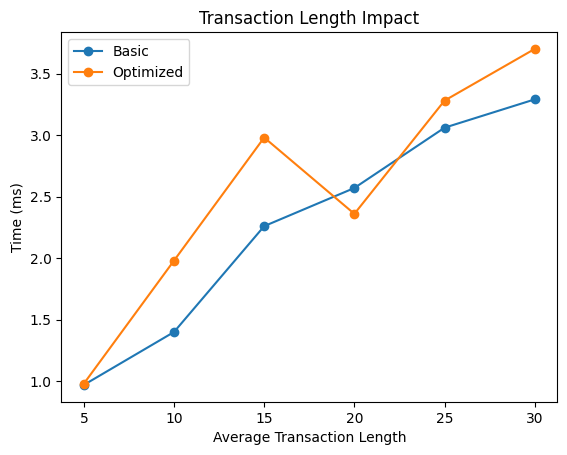

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

RESULTS_DIR = os.path.join(os.getcwd(), "..", "data", "results")

csv_files = [
    "correctness_results.csv",
    "time_fi_results.csv",
    "memory_results.csv",
    "scalability_results.csv",
    "txlen_results.csv"
]

dfs = {}

# Load CSV
for file in csv_files:
    path = os.path.join(RESULTS_DIR, file)
    if os.path.isfile(path):
        dfs[file] = pd.read_csv(path)
        print("✓ Loaded:", file)
    else:
        print("⚠ Missing:", file)

# =========================
# Correctness Results
# =========================
if "correctness_results.csv" in dfs:
    df = dfs["correctness_results.csv"]
    print("\n=== CORRECTNESS RESULTS ===")
    display(df)

# =========================
# Time & FI Benchmark
# =========================
if "time_fi_results.csv" in dfs:
    df = dfs["time_fi_results.csv"]
    print("\n=== TIME & FI RESULTS ===")
    display(df)

    df.plot(x="Dataset", y=["Time_Basic_ms", "Time_Opt_ms"], kind="bar", rot=45)
    plt.title("Execution Time")
    plt.ylabel("Time (ms)")
    plt.legend(["Basic", "Optimized"])
    plt.show()

# =========================
# Memory Benchmark
# =========================
if "memory_results.csv" in dfs:
    df = dfs["memory_results.csv"]
    print("\n=== MEMORY RESULTS ===")
    df.plot(
        x="Dataset",
        y=["Mem_Basic_MB", "Mem_Opt_MB"],
        kind="bar",
        rot=45
    )

    plt.title("Memory Usage")
    plt.ylabel("Memory (MB)")
    plt.legend(["Basic", "Optimized"])
    plt.show()

# =========================
# Scalability Results
# =========================
if "scalability_results.csv" in dfs:
    df = dfs["scalability_results.csv"]
    print("\n=== SCALABILITY RESULTS ===")
    display(df)

    plt.plot(df["Subset_Pct"], df["Time_Basic_ms"], marker="o", label="Basic")
    plt.plot(df["Subset_Pct"], df["Time_Opt_ms"], marker="o", label="Optimized")
    plt.title("Scalability: Time vs Data Size")
    plt.xlabel("Subset %")
    plt.ylabel("Time (ms)")
    plt.legend()
    plt.show()

# =========================
# Transaction Length Results
# =========================
if "txlen_results.csv" in dfs:
    df = dfs["txlen_results.csv"]
    print("\n=== TX LENGTH RESULTS ===")
    display(df)

    plt.plot(df["Avg_TxLen"], df["Time_Basic_ms"], marker="o", label="Basic")
    plt.plot(df["Avg_TxLen"], df["Time_Opt_ms"], marker="o", label="Optimized")
    plt.title("Transaction Length Impact")
    plt.xlabel("Average Transaction Length")
    plt.ylabel("Time (ms)")
    plt.legend()
    plt.show()

VẼ BIỂU ĐỒ YÊU CẦU (b) và (c)...


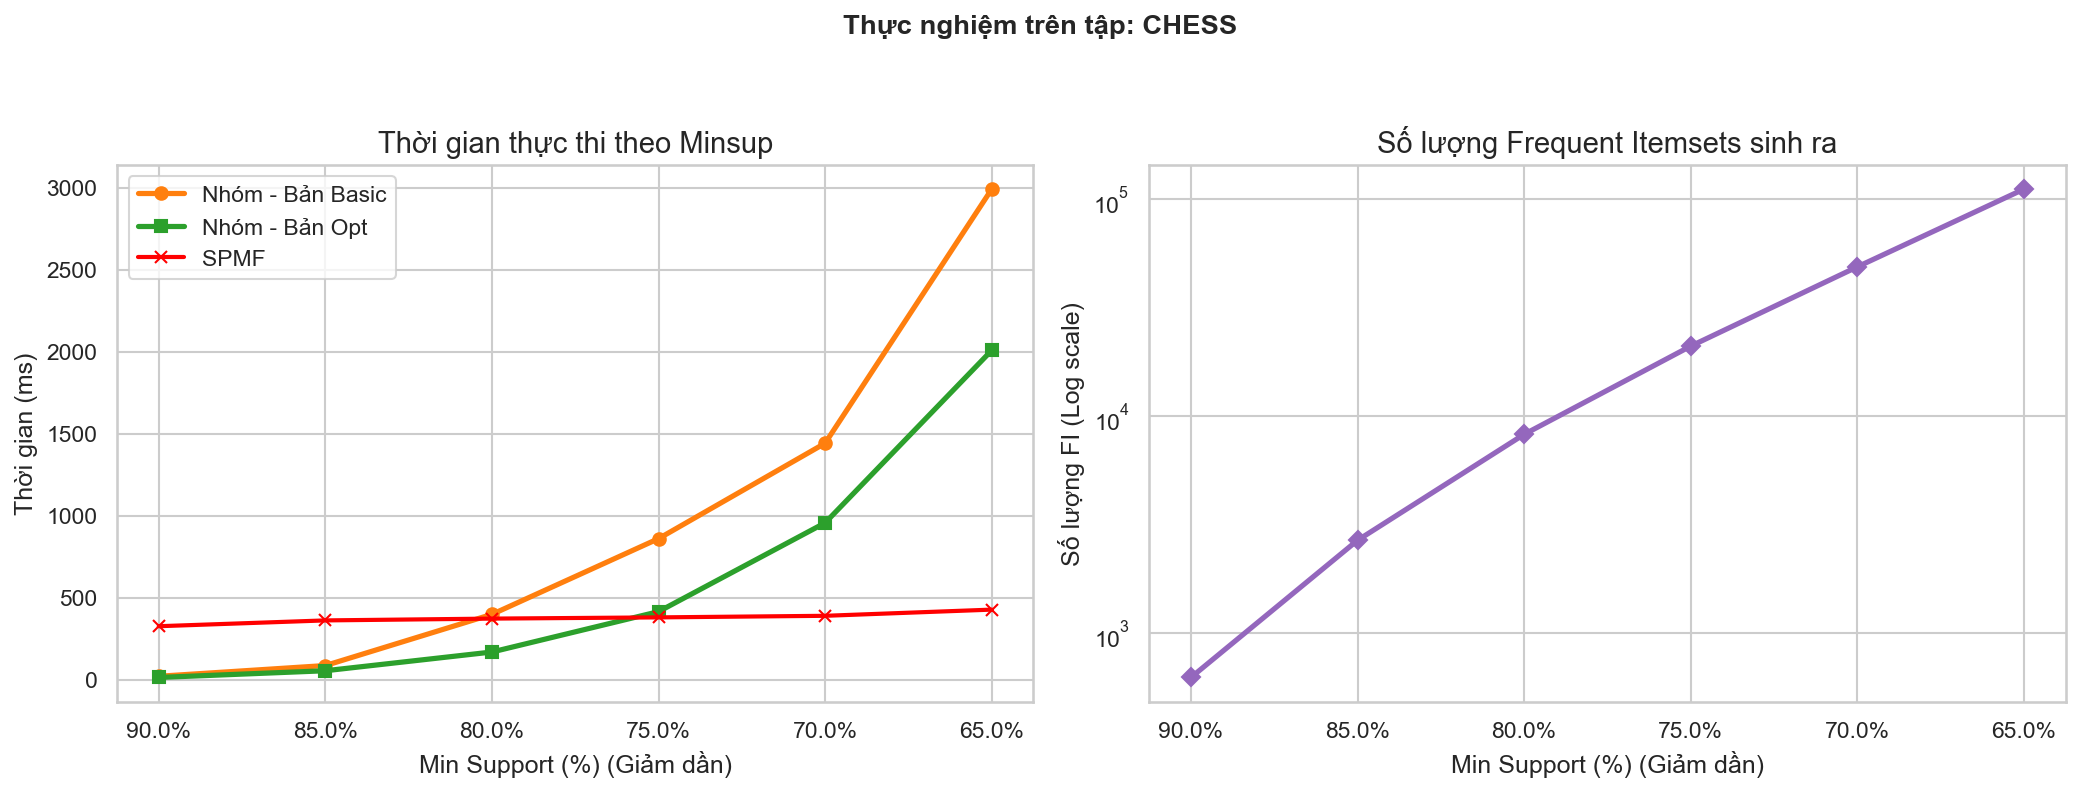

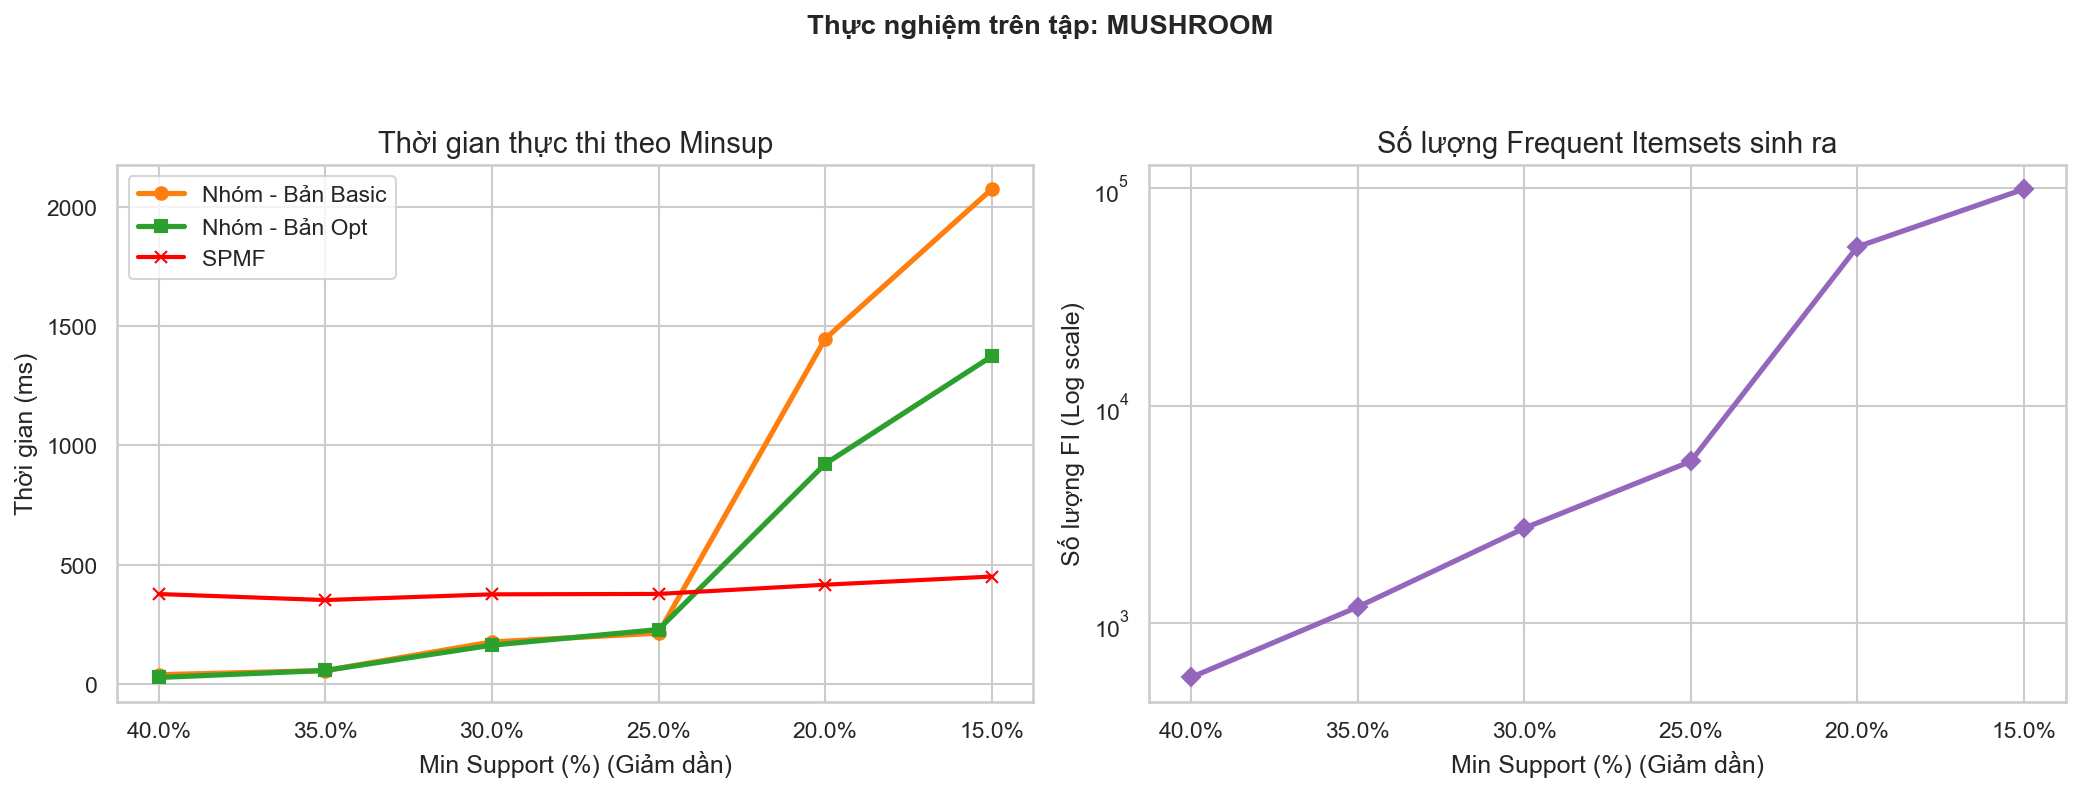

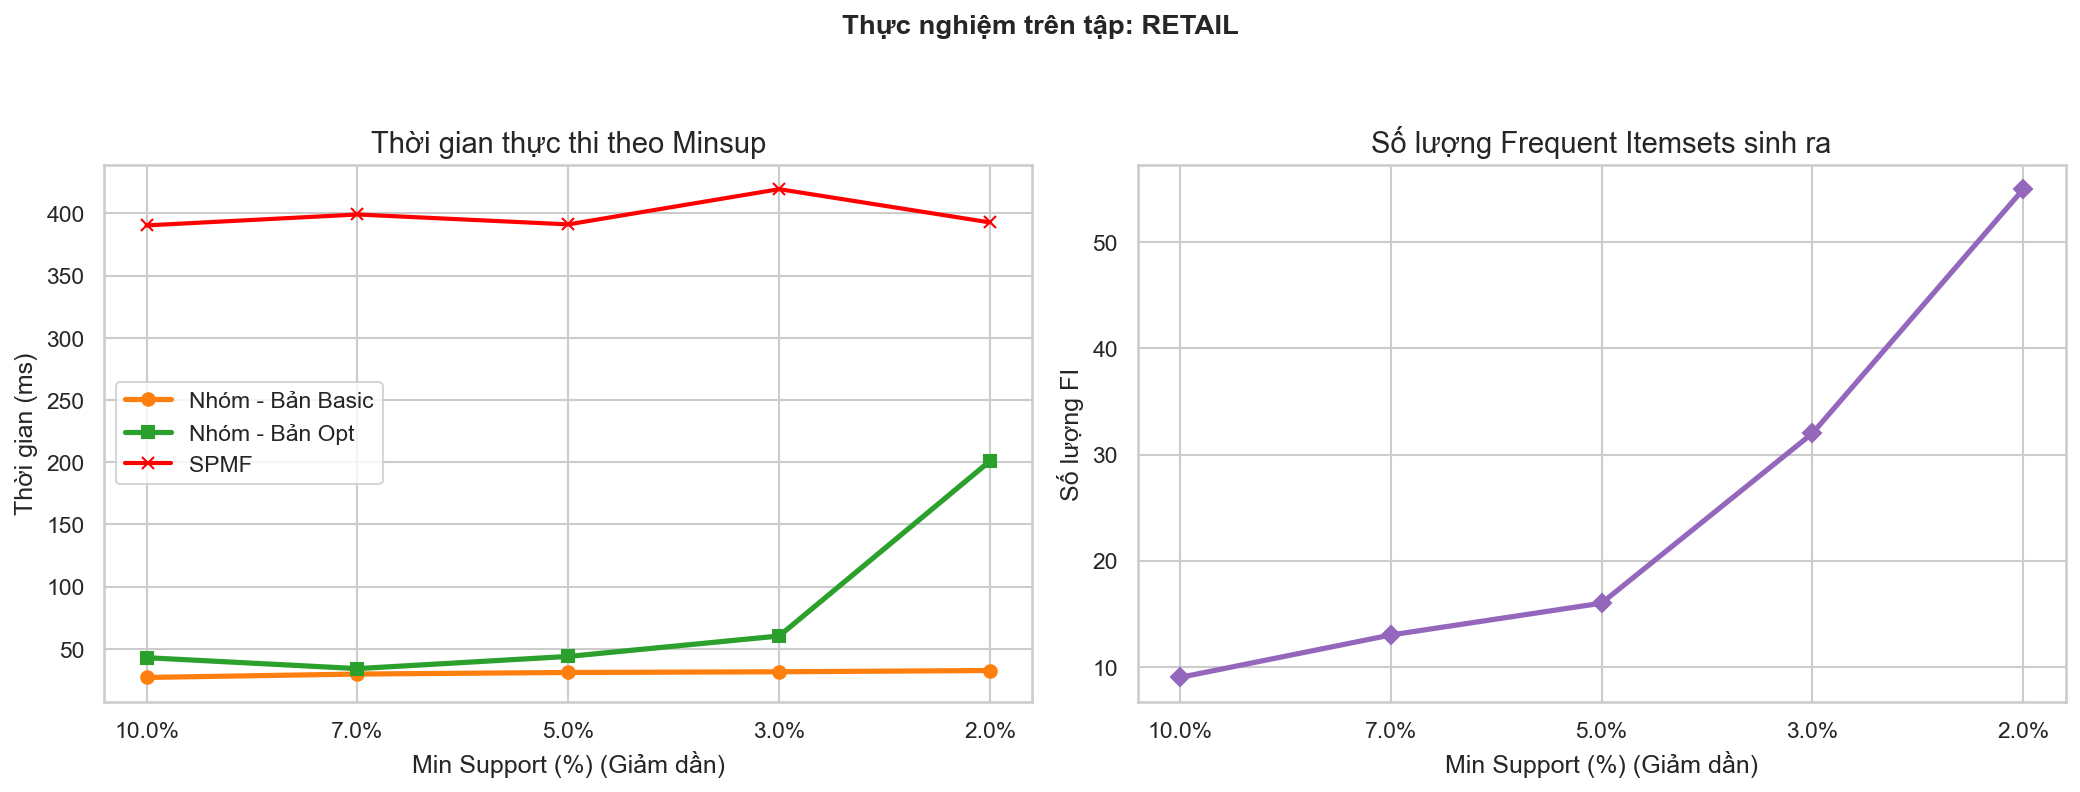

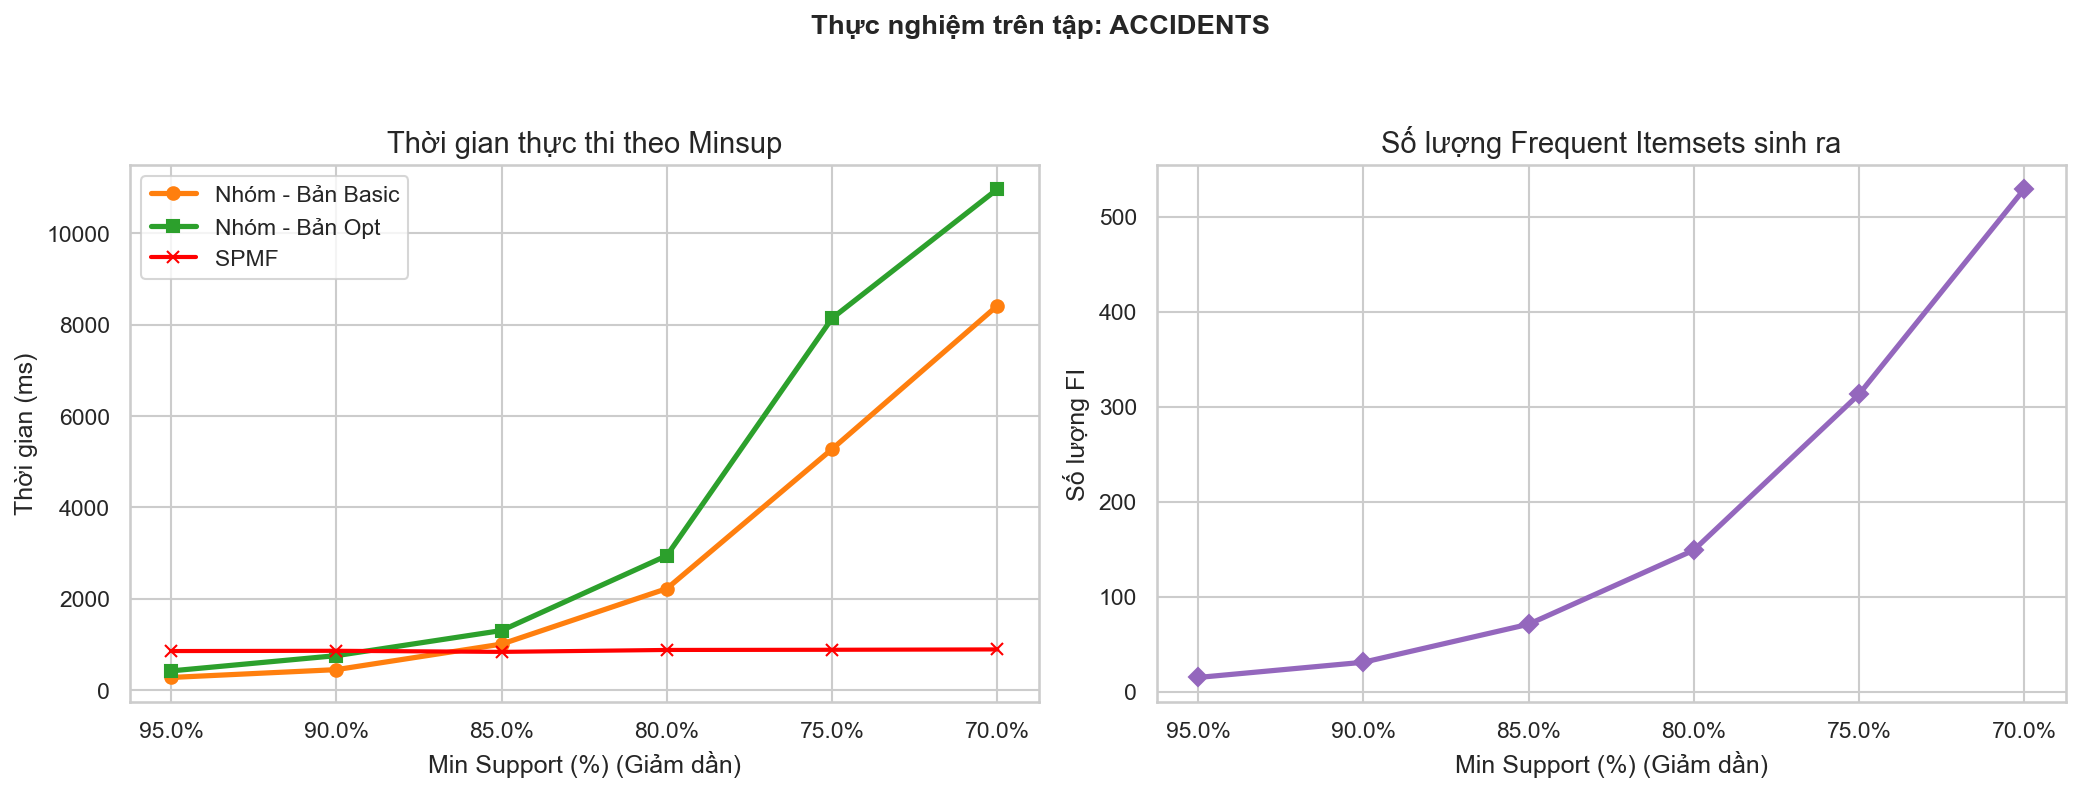

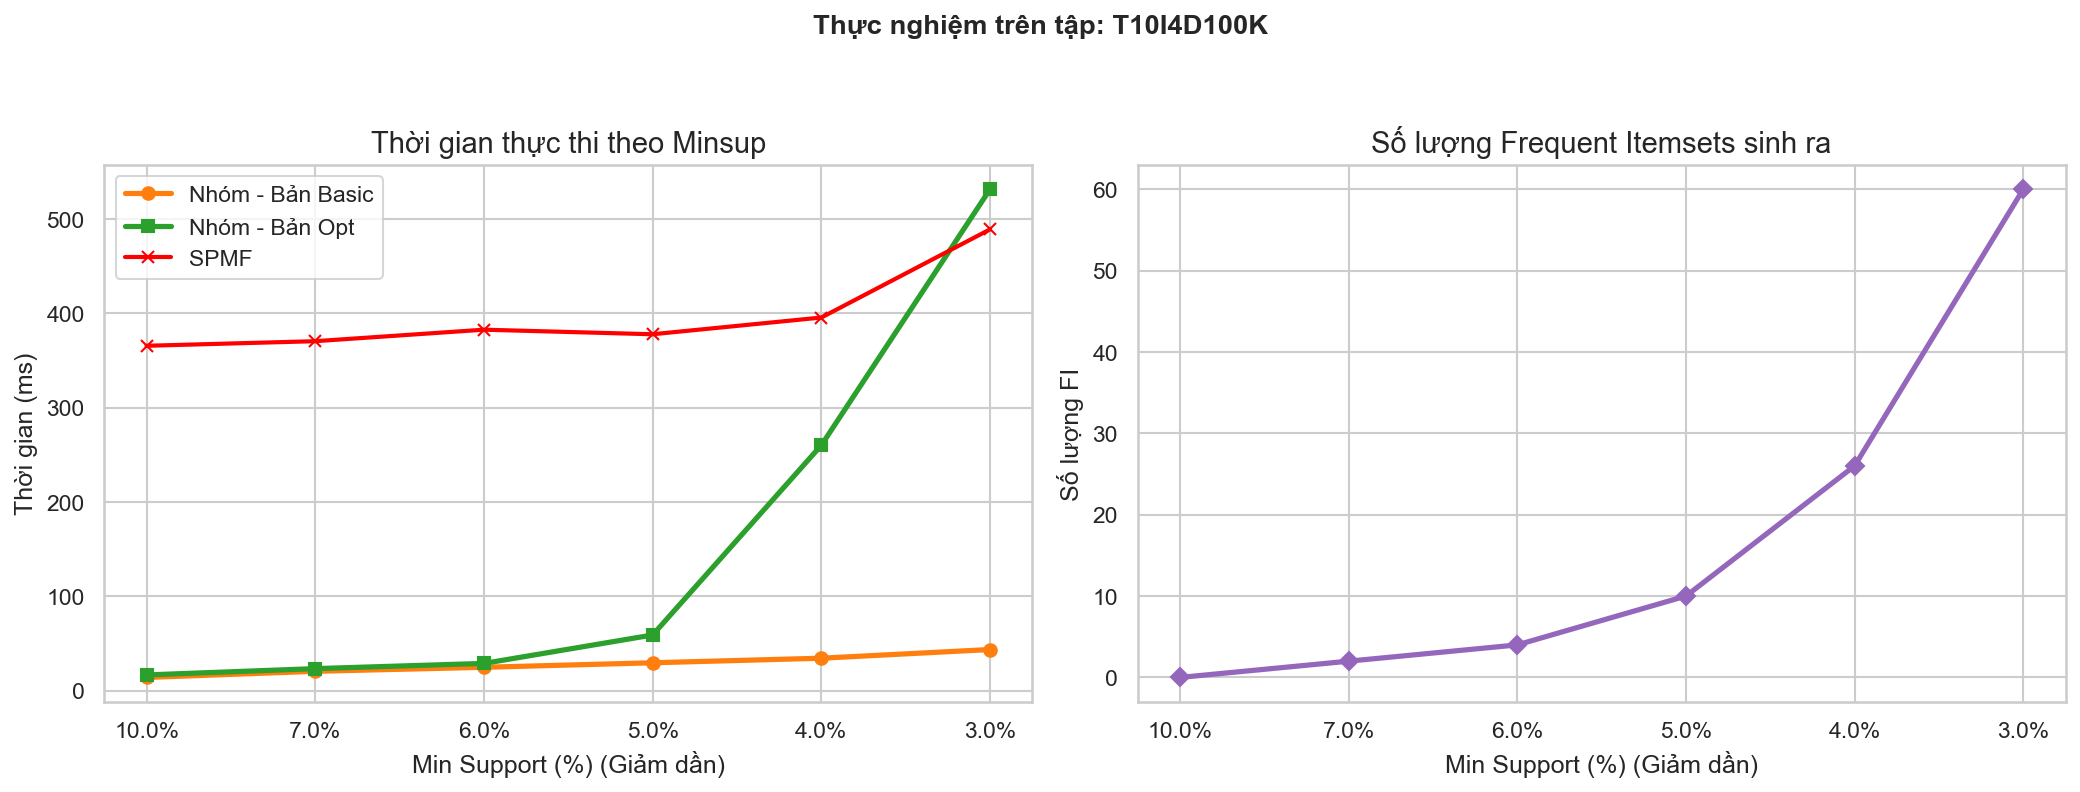


VẼ BIỂU ĐỒ YÊU CẦU (d) - BỘ NHỚ...


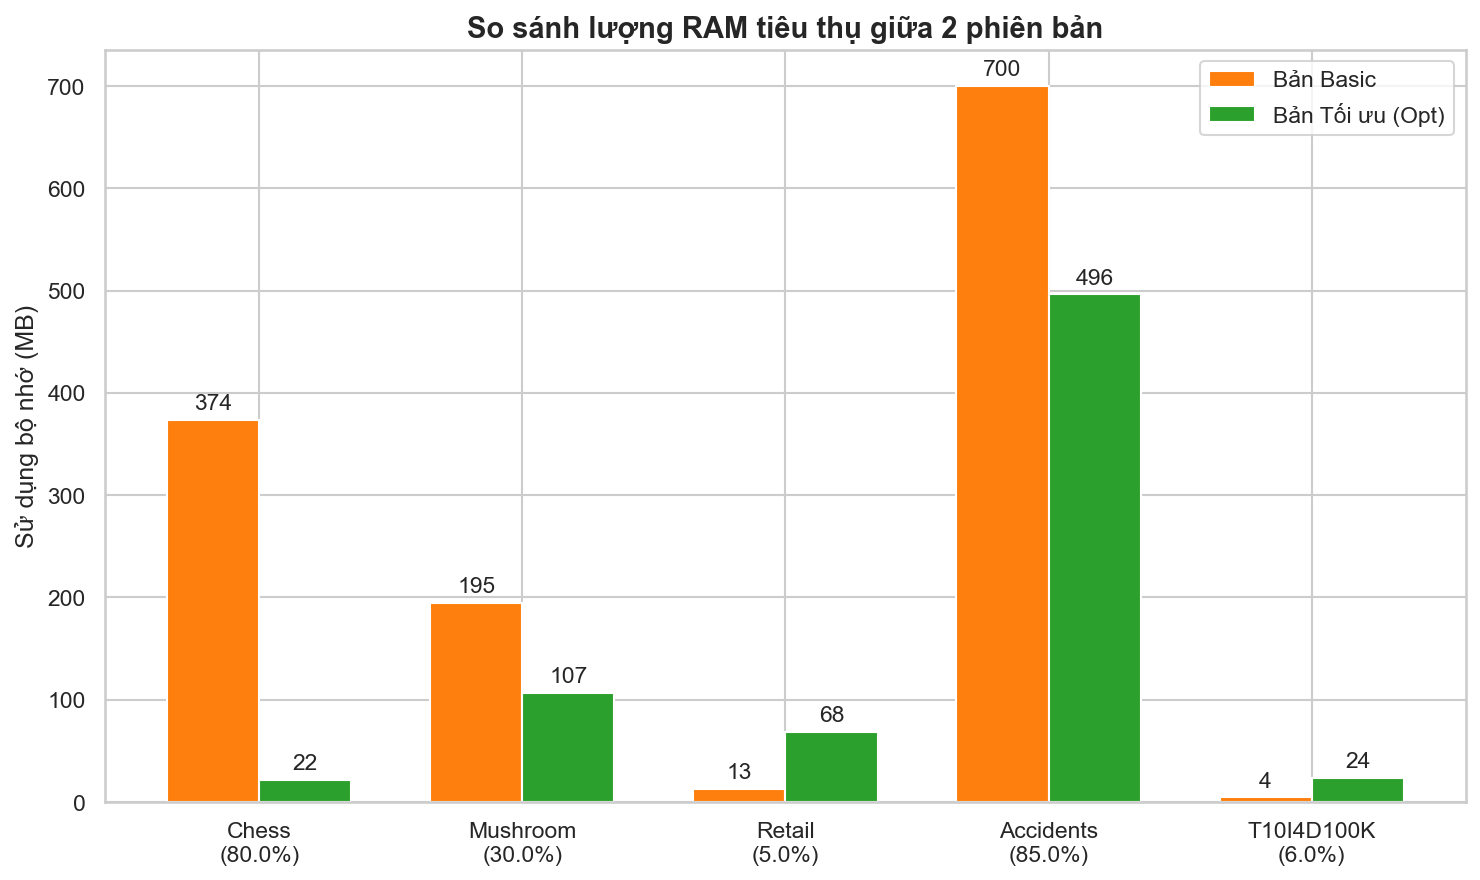


VẼ BIỂU ĐỒ YÊU CẦU (e) - SCALABILITY...


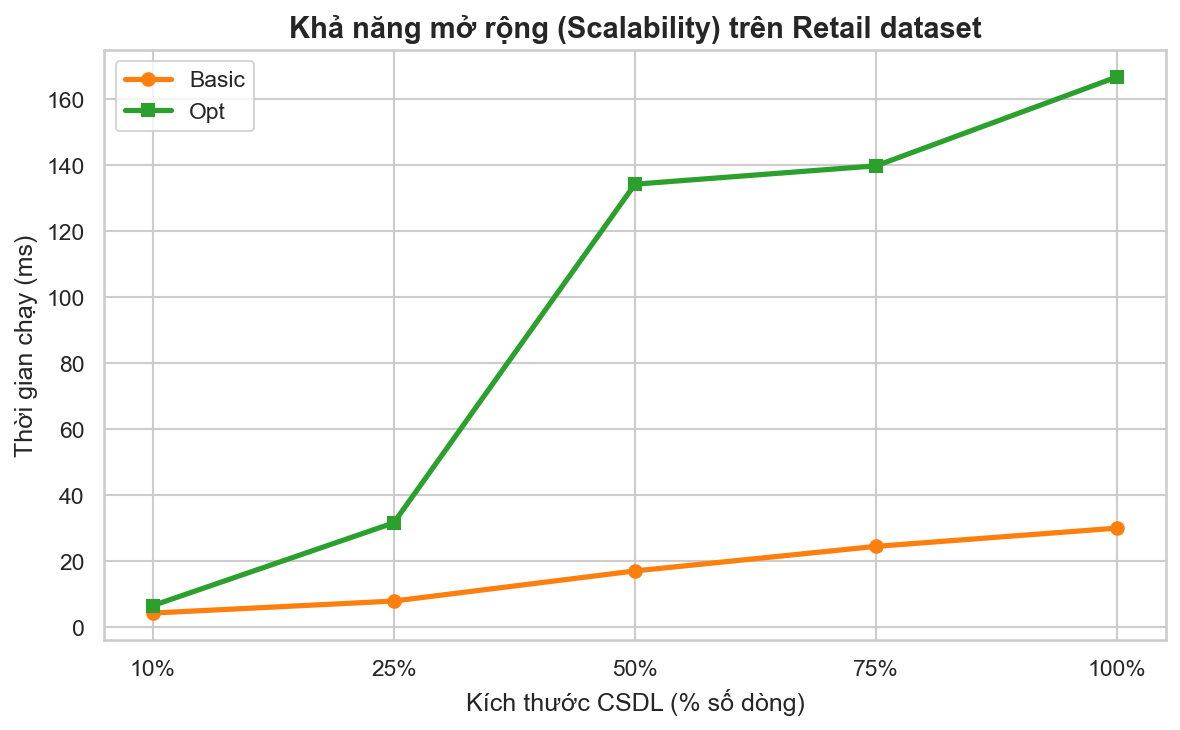


VẼ BIỂU ĐỒ YÊU CẦU (f) - TRANSACTION LENGTH...


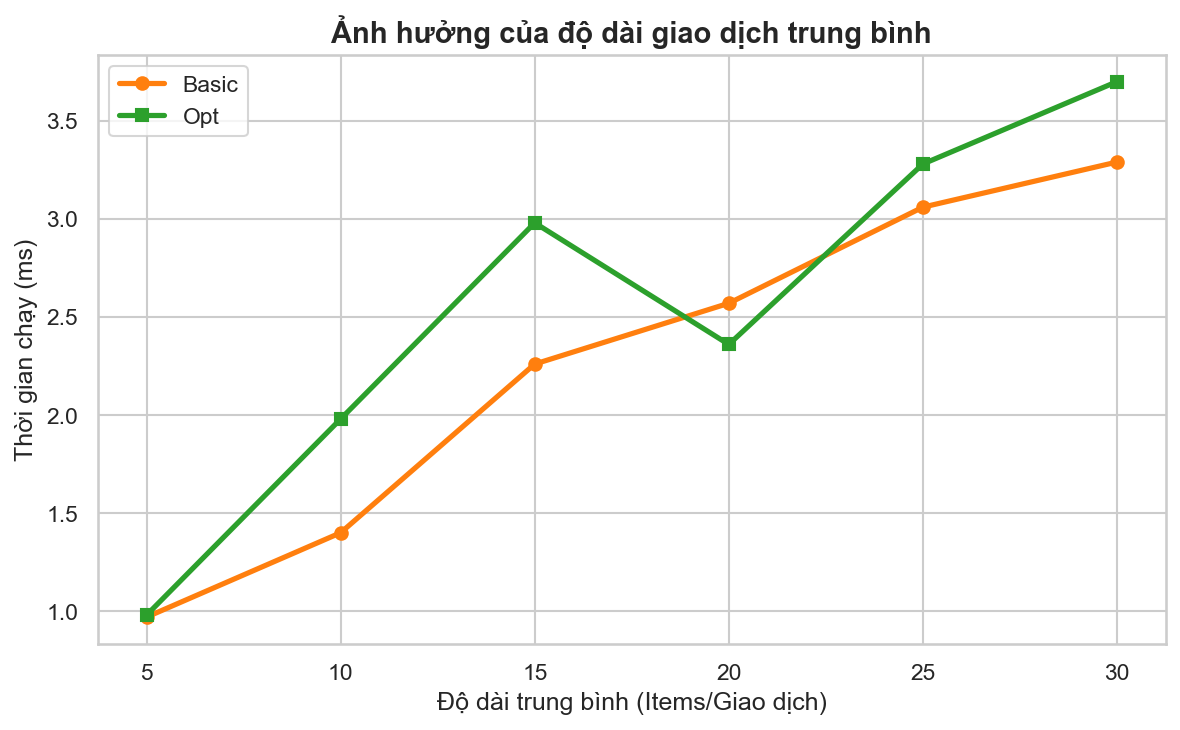

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập phong cách đồ thị chuẩn học thuật (Academic style)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150, 'axes.titlesize': 14})

# Đường dẫn thư mục chứa data
DATA_DIR = '../data/results/'

# =====================================================================
# YÊU CẦU (b) & (c): THỜI GIAN CHẠY & SỐ LƯỢNG FI THEO MINSUP
# =====================================================================
df_time = pd.read_csv(DATA_DIR + 'time_fi_results.csv')

datasets = df_time['Dataset'].unique()

print("VẼ BIỂU ĐỒ YÊU CẦU (b) và (c)...")
for ds in datasets:
    ds_data = df_time[df_time['Dataset'] == ds].sort_values('Minsup_Pct', ascending=False)
    x_labels = ds_data['Minsup_Pct'].astype(str) + '%'
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Thực nghiệm trên tập: {ds.upper()}', fontweight='bold', y=1.05)
    
    # Biểu đồ (b): Thời gian chạy
    axes[0].plot(x_labels, ds_data['Time_Basic_ms'], marker='o', color='#ff7f0e', label='Nhóm - Bản Basic', lw=2.5)
    axes[0].plot(x_labels, ds_data['Time_Opt_ms'], marker='s', color='#2ca02c', label='Nhóm - Bản Opt', lw=2.5)
    
    # Xử lý hiển thị SPMF (Nếu -1 thì không vẽ đường, chỉ ghi chú)
    spmf_valid = ds_data[ds_data['Time_SPMF_ms'] > 0]
    if not spmf_valid.empty:
        axes[0].plot(spmf_valid['Minsup_Pct'].astype(str)+'%', spmf_valid['Time_SPMF_ms'], marker='x', color='red', label='SPMF', lw=2)
    else:
        axes[0].text(0.5, 0.9, 'SPMF: Out of Memory (Crash)', transform=axes[0].transAxes, color='red', ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    axes[0].set_title('Thời gian thực thi theo Minsup')
    axes[0].set_xlabel('Min Support (%) (Giảm dần)')
    axes[0].set_ylabel('Thời gian (ms)')
    axes[0].legend()
    
    # Biểu đồ (c): Số lượng FI
    axes[1].plot(x_labels, ds_data['Num_FI'], marker='D', color='#9467bd', lw=2.5)
    axes[1].set_title('Số lượng Frequent Itemsets sinh ra')
    axes[1].set_xlabel('Min Support (%) (Giảm dần)')
    axes[1].set_ylabel('Số lượng FI (Log scale)' if ds_data['Num_FI'].max() > 10000 else 'Số lượng FI')
    if ds_data['Num_FI'].max() > 10000:
        axes[1].set_yscale('log')
        
    plt.tight_layout()
    plt.show()

# =====================================================================
# YÊU CẦU (d): SỬ DỤNG BỘ NHỚ (PEAK MEMORY)
# =====================================================================
print("\nVẼ BIỂU ĐỒ YÊU CẦU (d) - BỘ NHỚ...")
df_mem = pd.read_csv(DATA_DIR + 'memory_results.csv')

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_mem['Dataset']))
width = 0.35

rects1 = ax.bar(x - width/2, df_mem['Mem_Basic_MB'], width, label='Bản Basic', color='#ff7f0e')
rects2 = ax.bar(x + width/2, df_mem['Mem_Opt_MB'], width, label='Bản Tối ưu (Opt)', color='#2ca02c')

ax.set_ylabel('Sử dụng bộ nhớ (MB)')
ax.set_title('So sánh lượng RAM tiêu thụ giữa 2 phiên bản', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Dataset']}\n({row['Minsup_Pct']}%)" for _, row in df_mem.iterrows()])
ax.legend()

# Thêm số trên cột
ax.bar_label(rects1, padding=3, fmt='%.0f')
ax.bar_label(rects2, padding=3, fmt='%.0f')
plt.tight_layout()
plt.show()

# =====================================================================
# YÊU CẦU (e): SCALABILITY (KHẢ NĂNG MỞ RỘNG)
# =====================================================================
print("\nVẼ BIỂU ĐỒ YÊU CẦU (e) - SCALABILITY...")
df_scale = pd.read_csv(DATA_DIR + 'scalability_results.csv')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_scale['Subset_Pct'].astype(str) + '%', df_scale['Time_Basic_ms'], marker='o', lw=2.5, label='Basic', color='#ff7f0e')
ax.plot(df_scale['Subset_Pct'].astype(str) + '%', df_scale['Time_Opt_ms'], marker='s', lw=2.5, label='Opt', color='#2ca02c')

ax.set_title('Khả năng mở rộng (Scalability) trên Retail dataset', fontweight='bold')
ax.set_xlabel('Kích thước CSDL (% số dòng)')
ax.set_ylabel('Thời gian chạy (ms)')
ax.legend()
plt.tight_layout()
plt.show()

# =====================================================================
# YÊU CẦU (f): ẢNH HƯỞNG CỦA ĐỘ DÀI GIAO DỊCH
# =====================================================================
print("\nVẼ BIỂU ĐỒ YÊU CẦU (f) - TRANSACTION LENGTH...")
df_len = pd.read_csv(DATA_DIR + 'txlen_results.csv')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_len['Avg_TxLen'], df_len['Time_Basic_ms'], marker='o', lw=2.5, label='Basic', color='#ff7f0e')
ax.plot(df_len['Avg_TxLen'], df_len['Time_Opt_ms'], marker='s', lw=2.5, label='Opt', color='#2ca02c')

ax.set_title('Ảnh hưởng của độ dài giao dịch trung bình', fontweight='bold')
ax.set_xlabel('Độ dài trung bình (Items/Giao dịch)')
ax.set_ylabel('Thời gian chạy (ms)')
ax.legend()
plt.tight_layout()
plt.show()